In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import gc

In [2]:
df_2018_train = pd.read_parquet('../data/processed/2018/2018_train_scaled.parquet')
df_2018_test = pd.read_parquet('../data/processed/2018/2018_test_scaled.parquet')
df_2018 = pd.concat([df_2018_train,df_2018_test],ignore_index=True)
df_2018.shape

(16137183, 50)

In [3]:
del df_2018_train, df_2018_test
gc.collect()

0

In [4]:
X = df_2018.drop(columns=['Label'])
y = df_2018['Label']
nb_features = len(X.columns)

In [5]:
class DuelingQNetwork(nn.Module):
    def __init__(self, state_size, action_size):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(state_size, 128), 
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.LayerNorm(32),
            nn.ReLU(),
        )

        self.v = nn.Sequential(
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

        self.a = nn.Sequential(
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, action_size)
        )

    def forward(self, x):
        x = self.net(x)
        a = self.a(x)
        v = self.v(x)
        return v + (a - a.mean(dim=1, keepdim=True))

In [6]:
TEST_BATCH_SIZE = 4096

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
online_net = DuelingQNetwork(nb_features,2).to(device)
online_net.load_state_dict(torch.load('../models/dueling_dqn_2017.pth'))
online_net.eval()

y_pred = []
with torch.no_grad():
    for i in range(0, len(X), TEST_BATCH_SIZE):
        batch = torch.FloatTensor(X[i:i+TEST_BATCH_SIZE].values).to(device)
        q_values = online_net(batch)
        preds = q_values.argmax(dim=1).cpu().numpy()
        y_pred.extend(preds)

  
y_pred = np.array(y_pred)  

print(f"Classification Report  : \n{classification_report(y, y_pred)}")

Classification Report  : 
              precision    recall  f1-score   support

           0       0.96      0.85      0.90  13390249
           1       0.53      0.81      0.64   2746934

    accuracy                           0.84  16137183
   macro avg       0.74      0.83      0.77  16137183
weighted avg       0.88      0.84      0.86  16137183



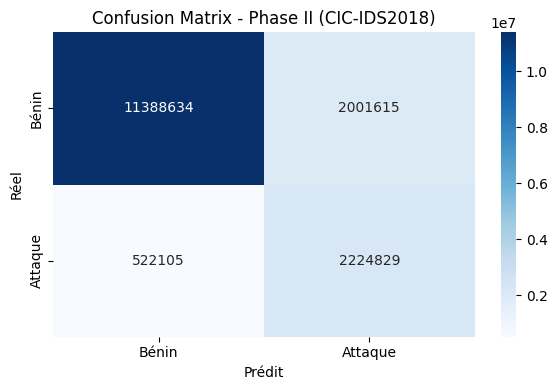

In [ ]:
cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bénin', 'Attaque'],
            yticklabels=['Bénin', 'Attaque'])
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Confusion Matrix - Phase II (CIC-IDS2018)")
plt.tight_layout()
plt.savefig("../figures/confusion_matrix_phase2.png", dpi=150)
plt.show()